In [1]:
import pandas as pd

# Path to your MAF file
maf_file = "data/mc3.v0.2.8.PUBLIC_segmeans_purity_cohort_gender.maf"

# Read the MAF file into a DataFrame.
# The 'comment' parameter skips any header lines that start with '#' (if present)
df = pd.read_csv(maf_file, sep="\t", comment="#", low_memory=False)

# Display the first few rows of the DataFrame
print(df.head())

  Hugo_Symbol  Entrez_Gene_Id Center NCBI_Build Chromosome  Start_Position  \
0       TACC2               0      .     GRCh37         10       123810032   
1     JAKMIP3               0      .     GRCh37         10       133967449   
2       PANX3               0      .     GRCh37         11       124489539   
3        SPI1               0      .     GRCh37         11        47380512   
4     NAALAD2               0      .     GRCh37         11        89868837   

   End_Position Strand Variant_Classification Variant_Type  ... FILTER  \
0     123810032      +      Missense_Mutation          SNP  ...   PASS   
1     133967449      +                 Silent          SNP  ...   PASS   
2     124489539      +      Missense_Mutation          SNP  ...   PASS   
3      47380512      +      Missense_Mutation          SNP  ...   PASS   
4      89868837      +      Missense_Mutation          SNP  ...   PASS   

                    COSMIC                                   CENTERS  \
0   SITE|p.T38

In [ ]:
import pickle as pkl

# Save the DataFrame to a pickle file
pkl.dump(df, open("data/mc3.pkl", "wb"))

In [1]:
import pandas as pd
import pickle as pkl

df = pkl.load(open("data/mc3.pkl", "rb"))
df.head()

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Variant_Classification,Variant_Type,...,FILTER,COSMIC,CENTERS,CONTEXT,DBVS,NCALLERS,Segment_Mean,Purity,Cohort,gender
0,TACC2,0,.,GRCh37,10,123810032,123810032,+,Missense_Mutation,SNP,...,PASS,SITE|p.T38M|c.113C>T|3,MUTECT|RADIA|SOMATICSNIPER|MUSE|VARSCANS,GGACACGCCCG,by1000G,5,-0.7607,0.9,GBM,MALE
1,JAKMIP3,0,.,GRCh37,10,133967449,133967449,+,Silent,SNP,...,PASS,NONE,MUTECT|RADIA|SOMATICSNIPER|MUSE|VARSCANS,CTGGACGAGGA,byFrequency,5,-0.7607,0.9,GBM,MALE
2,PANX3,0,.,GRCh37,11,124489539,124489539,+,Missense_Mutation,SNP,...,PASS,SITE|p.R296Q|c.887G>A|3,MUTECT|RADIA|SOMATICSNIPER|MUSE|VARSCANS,ATGTCGGTGGG,.,5,0.0569,0.9,GBM,MALE
3,SPI1,0,.,GRCh37,11,47380512,47380512,+,Missense_Mutation,SNP,...,PASS,NONE,RADIA|MUSE,GGCTGGGGACA,.,2,0.0605,0.9,GBM,MALE
4,NAALAD2,0,.,GRCh37,11,89868837,89868837,+,Missense_Mutation,SNP,...,PASS,SITE|p.R65C|c.193C>T|4,MUTECT|RADIA|SOMATICSNIPER|MUSE|VARSCANS,TTCTTCGGTAA,.,5,0.0569,0.9,GBM,MALE


In [2]:
# n_ref_count: The number of reads supporting the reference allele
# n_alt_count: The number of reads supporting the alternate allele
# t_alt_count: The number of reads supporting the alternate allele in the tumor sample

columns = ["Hugo_Symbol", "t_alt_count", "t_ref_count", "n_ref_count", "n_alt_count", "Segment_Mean", "Purity"]
data = df[columns]

Condition to filter out variant allele with copy number 2:
$$-0.3<=\text{Segment\_ Mean}<=0.3$$

In [3]:
# Remove rows with missing values in any of the columns
# Remove rows with Segment_Mean values outside the range [-0.3, 0.3], cuz we only want to work with allele having copy number 2
length0 = len(data)
data = data.dropna()
data = data[(data["Segment_Mean"]>=-0.3) & (data["Segment_Mean"]<=0.3)]
length1 = len(data)
print(f"Removed {length0 - length1} rows with missing values or Segment_Mean outside the range [-0.3, 0.3]")

Removed 1023425 rows with missing values or Segment_Mean outside the range [-0.3, 0.3]


## Distinguishing Clonal vs. Sub-Clonal Mutations in a DataFrame

Variant Allele Frequency (VAF):

$$ VAF = \frac{\texttt{t\textunderscore alt\textunderscore count}}{\texttt{t\textunderscore alt\textunderscore count}+\texttt{t\textunderscore ref\textunderscore count}} $$

Clonal mutations typically have a higher VAF (close to tumor purity).
Sub-clonal mutations have a lower VAF.
Purity of the Tumor Sample:
If VAF is close to purity, the mutation is clonal
If VAF is significantly lower than purity, the mutation is sub-clonal.

*"t" stands for tumor and "n" for normal. Each tumor has a paired normal sample (usually from the person's blood) which is used to filter out mutations that are not exclusive to the tumor but are found all cells of the person (we don't use the normals for everything ourselves though)*

*"more robust to use a **binomial test** (see https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.binomtest.html for example). We want a left-sided test where k = mutated reads, n = coverage, p = purity / 2. Then based on a p-value cutoff of 0.05 for instance you classify the mutations"*

In [5]:
from statsmodels.stats.proportion import binom_test
help(binom_test)

Help on function binom_test in module statsmodels.stats.proportion:

binom_test(count, nobs, prop=0.5, alternative='two-sided')
    Perform a test that the probability of success is p.

    This is an exact, two-sided test of the null hypothesis
    that the probability of success in a Bernoulli experiment
    is `p`.

    Parameters
    ----------
    count : {int, array_like}
        the number of successes in nobs trials.
    nobs : int
        the number of trials or observations.
    prop : float, optional
        The probability of success under the null hypothesis,
        `0 <= prop <= 1`. The default value is `prop = 0.5`
    alternative : str in ['two-sided', 'smaller', 'larger']
        alternative hypothesis, which can be two-sided or either one of the
        one-sided tests.

    Returns
    -------
    p-value : float
        The p-value of the hypothesis test

    Notes
    -----
    This uses scipy.stats.binom_test for the two-sided alternative.



In [ ]:
from statsmodels.stats.proportion import binom_test
# Chunk with longer excution time - the processed data will be saved to a pickle file
# Calculate Variant Allele Frequency (VAF)
# data["VAF"] = data["t_alt_count"] / (data["t_alt_count"] + data["t_ref_count"])

# Calculate the coverage of the mutation 
data['Coverage'] = data['t_alt_count'] + data['t_ref_count']

# Calculate the Binomial Test p-value
data["Binom_pval"] = data.apply(lambda row: binom_test(row["t_alt_count"], row["Coverage"], row["Purity"]*0.5, alternative="larger"), axis=1)

In [7]:
# TODO: Feature a binomial test to determine Clonality (DONE)

# Classify mutations using classic VAF v.s purity threshold
# data["Clonality0"] = data.apply(
#     lambda row: "Clonal" if row["VAF"] > row["Purity"] * 0.5 else "Sub-Clonal",
#     axis=1
# )

# Classify mutations using a binomial test
data["Clonality"] = data.apply(
    lambda row: "Clonal" if row["Binom_pval"] < 0.05 else "Sub-Clonal",
    axis=1
)

# Save the DataFrame to a pickle file
pkl.dump(data, open("data/mc3_binom.pkl", "wb"))

In [1]:
# Execute from this cell to load the data
import pickle as pkl
import pandas as pd
data = pkl.load(open("data/mc3_binom.pkl", "rb"))

In [2]:
print(data.columns)
data = data.reset_index(drop=True)
data["Clonality"] = data["Clonality"].astype(str)
data["Clonality"].value_counts()

Index(['Hugo_Symbol', 't_alt_count', 't_ref_count', 'n_ref_count',
       'n_alt_count', 'Segment_Mean', 'Purity', 'Coverage', 'Binom_pval',
       'Clonality'],
      dtype='object')


Clonality
Sub-Clonal    2307484
Clonal         270054
Name: count, dtype: int64

In [3]:
# Create a summary table of clonality counts
# Count occurrences of Clonality for each Hugo_Symbol
clonal_summary = data.groupby("Hugo_Symbol")["Clonality"].value_counts().unstack(fill_value=0)

# Rename columns for clarity
clonal_summary.columns.name = None  # Remove column index name
clonal_summary = clonal_summary.rename(columns={"Clonal": "Clonal Count", "Sub-Clonal": "Sub-Clonal Count"})

## Possion regression

$$ \log(\lambda) = \beta_0 + \beta_1 \cdot \text{Clonal Count} $$

Where $\lambda$ is the expected value of the response variable ($\text{Sub-Clonal Count}$).

In [16]:
import statsmodels.api as sm

# Define the predictor and response variables
x = clonal_summary["Clonal Count"]
y = clonal_summary["Sub-Clonal Count"]

# Add a constant to the predictor variable (intercept term)
x_with_const = sm.add_constant(x)

# Fit the Poisson regression model
poisson_model = sm.GLM(y, x_with_const, family=sm.families.Poisson()).fit()

# Print the summary of the model
print(poisson_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:       Sub-Clonal Count   No. Observations:                20541
Model:                            GLM   Df Residuals:                    20539
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -8.2836e+05
Date:                Fri, 21 Mar 2025   Deviance:                   1.5315e+06
Time:                        09:43:47   Pearson chi2:                 1.87e+06
No. Iterations:                    10   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            4.6547      0.001   6919.700   

In [17]:
# calculate the mean of the response variable by the predictor variable
group_means = []
xlim = 500
step = 1
for i in range(0, xlim, step):
    group_means.append(clonal_summary[(x >= i) & (x < i + step)]["Sub-Clonal Count"].mean())

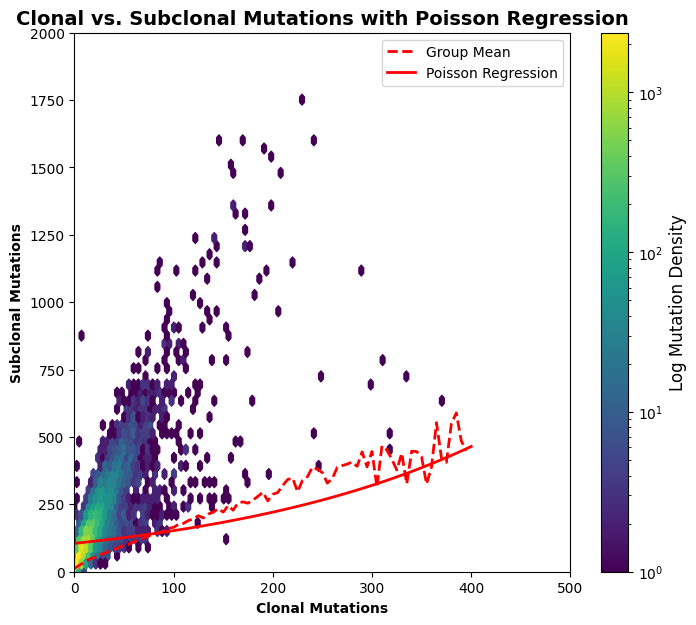

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm  # Ensure statsmodels is imported

# Generate values for prediction
x_plot = np.linspace(0, 400, 400)  # Generate 400 values between 0 and 400
step5_lim = 400  # Limit for x_step5
x_step5 = np.arange(0, step5_lim, 5)  # Generate values in steps of 5

# Create a design matrix for prediction (add an intercept)
x_pred = sm.add_constant(x_plot)  # Ensures it matches the Poisson model structure

# Predict the Sub-Clonal Count using the Poisson regression model
predicted_counts = poisson_model.predict(x_pred)  # Use the corrected matrix

# Create the Hexbin Plot (R-style)
fig, ax = plt.subplots(figsize=(8, 7))
hb = ax.hexbin(
    clonal_summary["Clonal Count"], clonal_summary["Sub-Clonal Count"], 
    gridsize=300, cmap="viridis", bins="log", mincnt=1  # Use log scale for density
)

# Add the Group Means
ax.plot(x_step5, group_means[0:step5_lim//5], color="red", linestyle="--", linewidth=2, label="Group Mean")

# Add the Poisson Regression Line
ax.plot(x_plot, predicted_counts, color="red", linestyle="-", linewidth=2, label="Poisson Regression")

# Improve Labels and Title (ggplot2-like styling)
ax.set_xlim([0, xlim])  # Adjust these values based on your data
ax.set_ylim([0, 2000])  # Adjust these values based on your data
ax.set_xlabel("Clonal Mutations", fontsize=10, fontweight="bold")
ax.set_ylabel("Subclonal Mutations", fontsize=10, fontweight="bold")
ax.set_title("Clonal vs. Subclonal Mutations with Poisson Regression", fontsize=14, fontweight="bold")

# Add a Colorbar for Density
cb = fig.colorbar(hb, ax=ax)
cb.set_label("Log Mutation Density", fontsize=12)

ax.legend()  # Show the legend

# Show the Plot
plt.show()

The visualizations below applies methods to filter out outliers for n-D scatter plots, there are not useful for this use case but could be useful later

---

## Appendix

To have a better visualization of regression relationship, I filtered out outliers using seperatly Interquantile Range and Z-Score. 

**IQR**
This method calculates 25th and 75th quantile then preserve only the data within this quantile for x and y 

**Z-Score**
$$ Z = \frac{X-\mu}{\sigma} $$ 
If $|Z| \leq 3$ then it's considered as an outlier. 


NO NEED to filter out the outliers for the regression

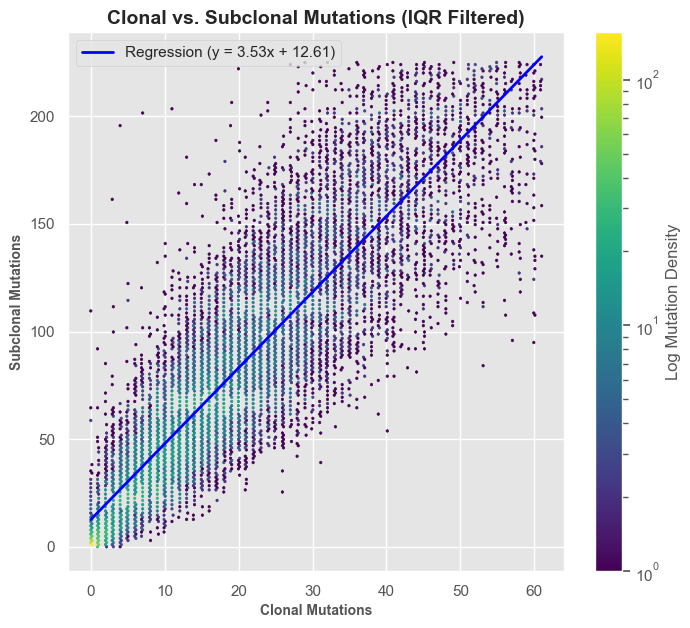

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import linregress

# Set R-style theme (ggplot2-like styling)
sns.set_theme(style="whitegrid")  # Equivalent to ggplot2's `theme_minimal()`
plt.style.use("ggplot")  # Ensures a ggplot2-style background

# Compute IQR and Remove Outliers**
def iqr_filter(df, column):
    """Filter data based on IQR range for a given column."""
    Q1, Q3 = np.percentile(df[column], [25, 75])
    IQR = Q3 - Q1
    lower_bound, upper_bound = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Apply IQR filtering on both Clonal and Sub-Clonal counts
filtered_data = iqr_filter(clonal_summary, "Clonal Count")
filtered_data = iqr_filter(filtered_data, "Sub-Clonal Count")

# Extract filtered data
x_filtered = filtered_data["Clonal Count"]
y_filtered = filtered_data["Sub-Clonal Count"]

# Fit a linear regression model to the filtered data
slope, intercept, r_value, p_value, std_err = linregress(x_filtered, y_filtered)

# Generate regression line
x_vals = np.linspace(min(x_filtered), max(x_filtered), 100)
y_vals = slope * x_vals + intercept

# Create the Hexbin Plot (R-style)
fig, ax = plt.subplots(figsize=(8, 7))
# sns.histplot(data=filtered_data, x="Clonal Count", y="Sub-Clonal Count", bins=100, ax=ax, cmap="viridis", cbar=True, cbar_kws={"label": "Density"})
hb = ax.hexbin(x_filtered, y_filtered, gridsize=200, cmap="viridis", bins="log", mincnt=1)  # Use log scale for density

# Add a Regression Line (ggplot2-like)
ax.plot(x_vals, y_vals, color="blue", linestyle="-", linewidth=2, label=f"Regression (y = {slope:.2f}x + {intercept:.2f})")

# # Add a Diagonal Reference Line (y = x)
# max_val = max(x_filtered.max(), y_filtered.max())
# ax.plot([0, max_val], [0, max_val], color="red", linestyle="dashed", linewidth=1)  # Similar to `geom_abline()`

# Improve Labels and Title (ggplot2-like styling)
ax.set_xlabel("Clonal Mutations", fontsize=10, fontweight="bold")
ax.set_ylabel("Subclonal Mutations", fontsize=10, fontweight="bold")
ax.set_title("Clonal vs. Subclonal Mutations (IQR Filtered)", fontsize=14, fontweight="bold")

# Add a Colorbar for Density (ggplot2-like)
cb = fig.colorbar(hb, ax=ax)
cb.set_label("Log Mutation Density", fontsize=12)

ax.legend()  # Show the legend
# Remove Unnecessary Spines (Cleaner ggplot2 style)
# sns.despine(left=True, bottom=True)

# Show the Plot
plt.show()

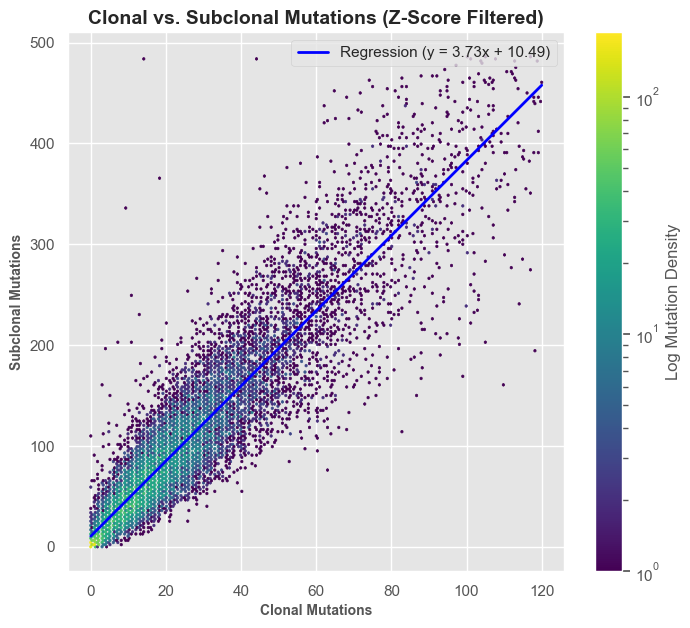

In [8]:
from scipy.stats import zscore

# Compute Z-scores
z_scores = np.abs(zscore(clonal_summary[["Clonal Count", "Sub-Clonal Count"]]))

# Set threshold for outliers (e.g., 3 standard deviations)
filtered_data = clonal_summary[(z_scores < 3).all(axis=1)]

# Extract filtered data
x_filtered = filtered_data["Clonal Count"]
y_filtered = filtered_data["Sub-Clonal Count"]

# Fit a linear regression model to the filtered data
slope, intercept, r_value, p_value, std_err = linregress(x_filtered, y_filtered)

# Generate regression line
x_vals = np.linspace(min(x_filtered), max(x_filtered), 100)
y_vals = slope * x_vals + intercept

# Create the Hexbin Plot (R-style)
fig, ax = plt.subplots(figsize=(8, 7))
hb = ax.hexbin(x_filtered, y_filtered, gridsize=200, cmap="viridis", bins="log", mincnt=1)  # Use log scale for density

# Add a Regression Line (ggplot2-like)
ax.plot(x_vals, y_vals, color="blue", linestyle="-", linewidth=2, label=f"Regression (y = {slope:.2f}x + {intercept:.2f})")

# # Add a Diagonal Reference Line (y = x)
# max_val = max(x_filtered.max(), y_filtered.max())
# ax.plot([0, max_val], [0, max_val], color="red", linestyle="dashed", linewidth=1)  # Similar to `geom_abline()`

# Improve Labels and Title (ggplot2-like styling)
ax.set_xlabel("Clonal Mutations", fontsize=10, fontweight="bold")
ax.set_ylabel("Subclonal Mutations", fontsize=10, fontweight="bold")
ax.set_title("Clonal vs. Subclonal Mutations (Z-Score Filtered)", fontsize=14, fontweight="bold")

# Add a Colorbar for Density (ggplot2-like)
cb = fig.colorbar(hb, ax=ax)
cb.set_label("Log Mutation Density", fontsize=12)

ax.legend()  # Show the legend
# Remove Unnecessary Spines (Cleaner ggplot2 style)
# sns.despine(left=True, bottom=True)

# Show the Plot
plt.show()

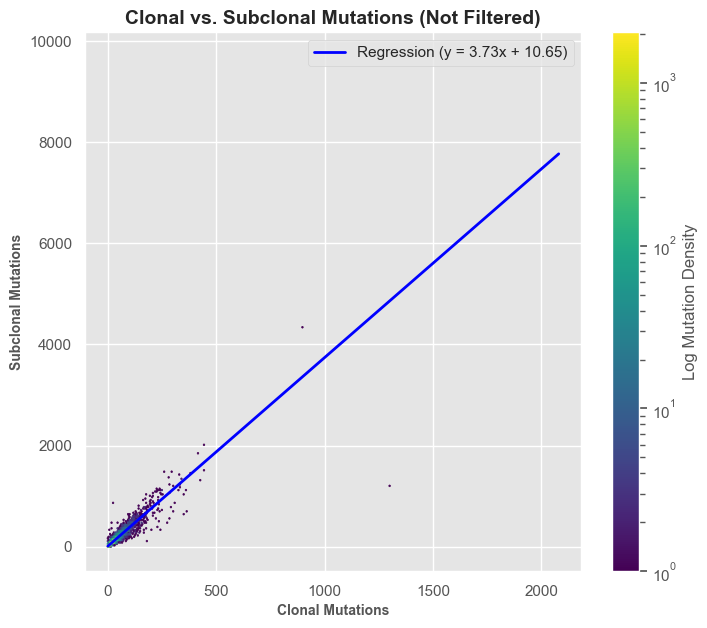

In [9]:
# Extract filtered data
x = clonal_summary["Clonal Count"]
y = clonal_summary["Sub-Clonal Count"]

# Fit a linear regression model to the filtered data
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# Generate regression line
x_vals = np.linspace(min(x), max(x), 100)
y_vals = slope * x_vals + intercept

# Create the Hexbin Plot (R-style)
fig, ax = plt.subplots(figsize=(8, 7))
hb = ax.hexbin(x, y, gridsize=300, cmap="viridis", bins="log", mincnt=1)  # Use log scale for density

# Add a Regression Line (ggplot2-like)
ax.plot(x_vals, y_vals, color="blue", linestyle="-", linewidth=2, label=f"Regression (y = {slope:.2f}x + {intercept:.2f})")

# # Add a Diagonal Reference Line (y = x)
# max_val = max(x_filtered.max(), y_filtered.max())
# ax.plot([0, max_val], [0, max_val], color="red", linestyle="dashed", linewidth=1)  # Similar to `geom_abline()`

# Improve Labels and Title (ggplot2-like styling)
ax.set_xlabel("Clonal Mutations", fontsize=10, fontweight="bold")
ax.set_ylabel("Subclonal Mutations", fontsize=10, fontweight="bold")
ax.set_title("Clonal vs. Subclonal Mutations (Not Filtered)", fontsize=14, fontweight="bold")

# Add a Colorbar for Density (ggplot2-like)
cb = fig.colorbar(hb, ax=ax)
cb.set_label("Log Mutation Density", fontsize=12)

ax.legend()  # Show the legend
# Remove Unnecessary Spines (Cleaner ggplot2 style)
# sns.despine(left=True, bottom=True)

# Show the Plot
plt.show()

Do Poisson tests to the data frame clonal summary